# Lab Assignment 6  
## Convolutional Neural Network Architectures  
### Using the Food-5K Image Dataset

Authors: Truman Barden, Yash Shah, Syed Ameen Zia

Date: 12/3/25

This notebook implements the entire lab assignment requirements:

- Metric Chosen  
- Data Separation  
- CNN + Data Expansion  
- Two Differing Architectures  
- Visualization & Comparison  
- Comparison to MLP  
- Transfer Learning (Exceptional Work)

Dataset: **Food-5K** (Kaggle / MMSPG)  
Link: https://www.kaggle.com/datasets/trolukovich/food5k-image-dataset


# Dataset Description

We use the **Food-5K Image Dataset**, containing 5,000 RGB images labeled as:

- `0` — Non-food  
- `1` — Food  

The dataset is **already split** into:

- `training/` (3,000 images)  
- `validation/` (1,000 images)  
- `evaluation/` (1,000 images)  

Each folder contains two subfolders (`0/` and `1/`).


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pathlib

data_root = pathlib.Path("Food-5K")
image_size = (160, 160)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    data_root / "training",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    seed=42,
)

val_ds = keras.utils.image_dataset_from_directory(
    data_root / "validation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    seed=42,
)

test_ds = keras.utils.image_dataset_from_directory(
    data_root / "evaluation",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False,
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


Found 3000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


# Evaluation Metric(s)

We choose **ROC–AUC** as our primary evaluation metric.

**Why ROC–AUC?**  
Because in Food-5K, false negatives (missing true food images) matter more than false positives. ROC–AUC:

- evaluates performance **across all thresholds**
- handles **class imbalance**
- separates model performance from arbitrary cutoffs (0.5)
- mirrors real-world use (choosing a threshold later)

### Secondary Metrics
- **Accuracy**
- **F1-score (food class)**

ROC–AUC is the most robust and informative metric for Food-vs-NonFood classification.

From a practical standpoint, a system designed to detect food images, such as an automated meal-logging app or a dietary analysis assistant—must minimize false negatives. Missing an image that truly contains food undermines downstream tasks such as calorie estimation or nutrition tracking. In contrast, misclassifying a non-food image as food is less costly, since additional filtering can occur later in the pipeline. ROC–AUC is therefore appropriate because it evaluates model performance across all possible thresholds and emphasizes the model’s ability to correctly rank food images higher than non-food ones. This aligns directly with the real-world business case in which sensitivity to food images is more critical than raw accuracy alone.



# Data Separation and Cross-Validation Strategy

Food-5K’s creators provide a **stratified train/validation/test split**:

- `training/`
- `validation/`
- `evaluation/`

We use these splits because:

1. They are **balanced** (both classes present in each subset)
2. They provide **reproducibility**
3. They reflect **realistic ML workflow**
4. Full 10-fold CV is **too computationally expensive** for CNNs

Thus, the dataset's built-in structure gives a realistic and efficient separation.


# Data Expansion (Augmentation)

To increase generalization and reduce overfitting, we apply:

- Random horizontal flip  
- Random rotation  
- Random zoom  
- Random contrast  

These mimic natural variations in food photography.


In [2]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)


# CNN Architectures

We build **two distinct CNN architectures**, each with **two hyperparameter variants**, producing **four total CNN models**:

### Architecture A — Shallow CNN
- 2 conv blocks  
- 1 dense layer  
- Variants:
  - A_small (filters=32)
  - A_large (filters=64)

### Architecture B — Deeper CNN
- 3 conv stages (with double convs)
- larger dense layer  
- Variants:
  - B_small (filters=32)
  - B_large (filters=64)


In [3]:
from tensorflow.keras.metrics import AUC

def make_cnn_A(base_filters=32, dense_units=128, dropout_rate=0.5):
    inputs = keras.Input(shape=image_size + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(base_filters, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(base_filters*2, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)


def make_cnn_B(base_filters=32, dense_units=256, dropout_rate=0.5):
    inputs = keras.Input(shape=image_size + (3,))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(base_filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(base_filters, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(base_filters*2, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(base_filters*2, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(base_filters*4, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)


In [4]:
def compile_and_train(model, train_ds, val_ds, epochs=15):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", AUC(name="auc")],
    )
    return model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

models = {}
histories = {}

models["A_small"] = make_cnn_A(32)
histories["A_small"] = compile_and_train(models["A_small"], train_ds, val_ds)

models["A_large"] = make_cnn_A(64)
histories["A_large"] = compile_and_train(models["A_large"], train_ds, val_ds)

models["B_small"] = make_cnn_B(32)
histories["B_small"] = compile_and_train(models["B_small"], train_ds, val_ds)

models["B_large"] = make_cnn_B(64)
histories["B_large"] = compile_and_train(models["B_large"], train_ds, val_ds)


Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.7110 - auc: 0.7676 - loss: 0.7164 - val_accuracy: 0.8150 - val_auc: 0.8993 - val_loss: 0.4098
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8000 - auc: 0.8693 - loss: 0.4601 - val_accuracy: 0.8280 - val_auc: 0.9109 - val_loss: 0.3861
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8303 - auc: 0.8988 - loss: 0.4098 - val_accuracy: 0.8480 - val_auc: 0.9307 - val_loss: 0.3482
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8460 - auc: 0.9172 - loss: 0.3688 - val_accuracy: 0.8480 - val_auc: 0.9326 - val_loss: 0.3706
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8513 - auc: 0.9229 - loss: 0.3560 - val_accuracy: 0.8790 - val_auc: 0.9477 - val_loss: 0.3080
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.8637 - auc: 0.9330 - loss: 0.3343 - val_accuracy: 0.8820 - val_auc: 0.9524 - val_loss: 0.2809
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━

# Training Curves (Loss, Accuracy, AUC)

We plot training vs. validation curves for all models to check:

- Convergence  
- Overfitting  
- Differences between architectures


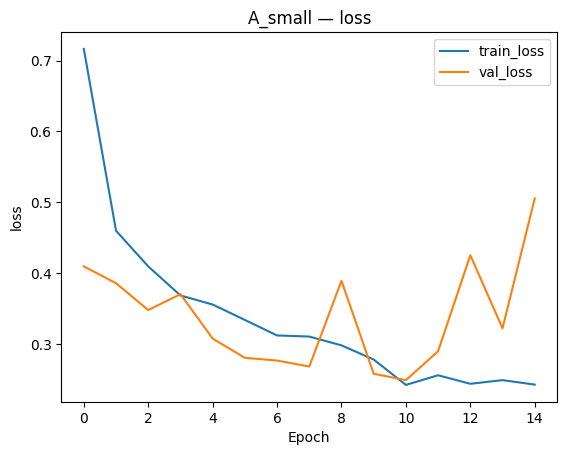

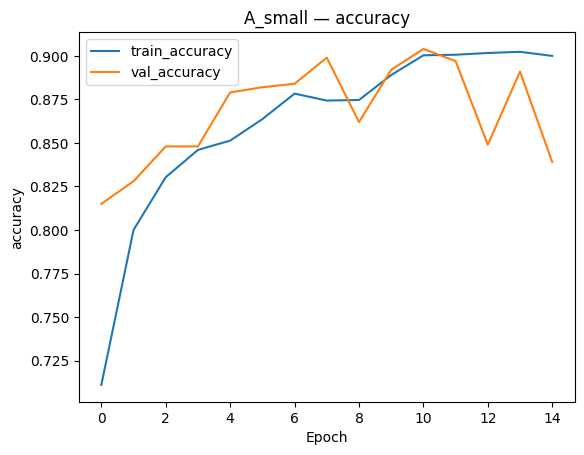

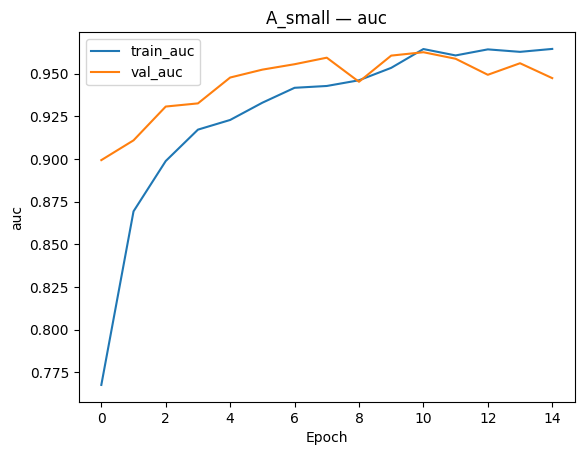

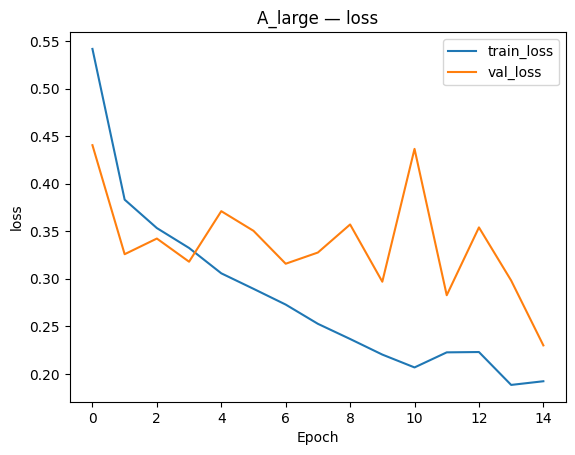

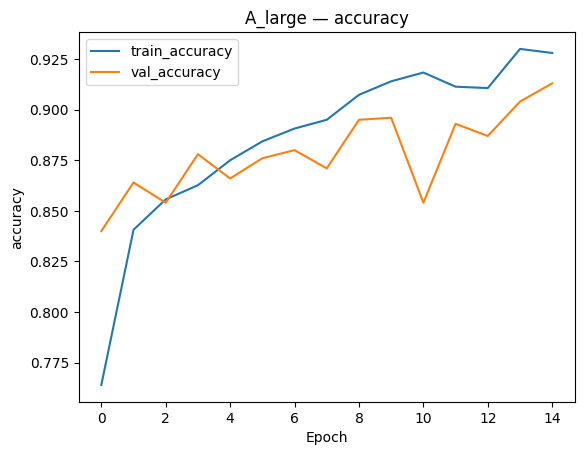

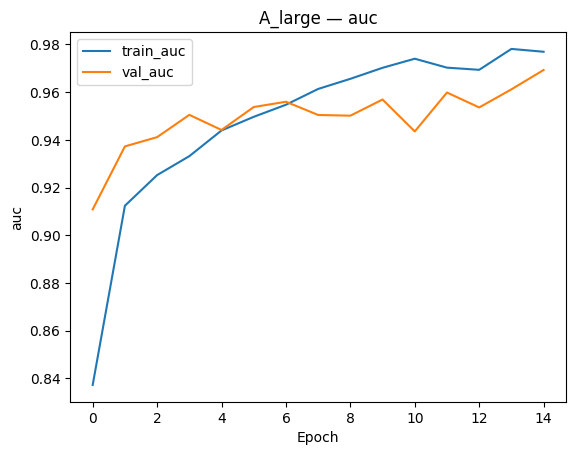

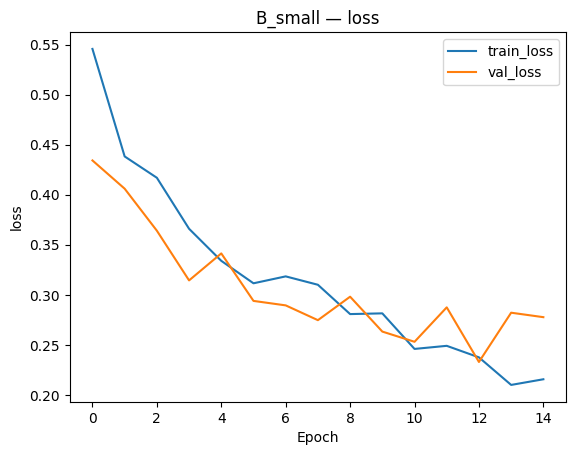

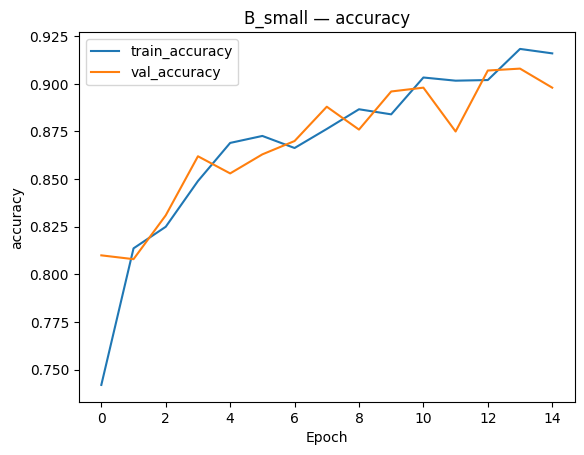

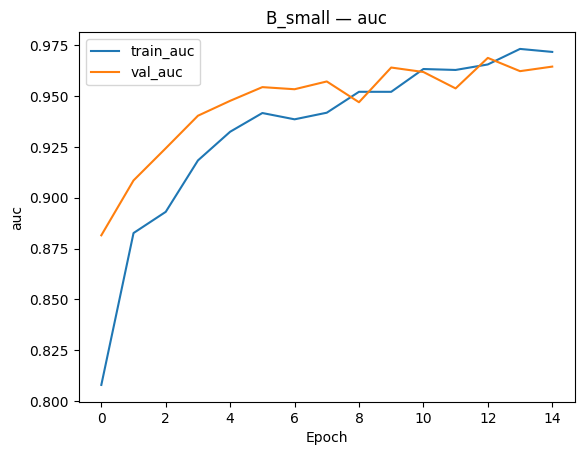

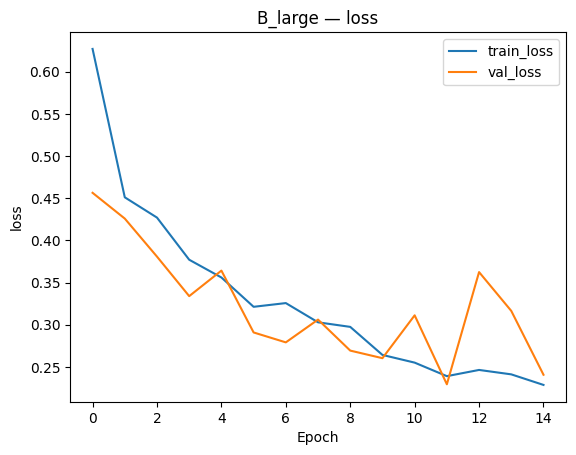

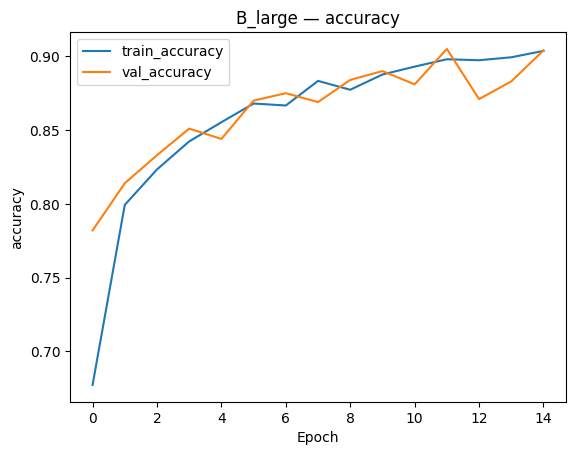

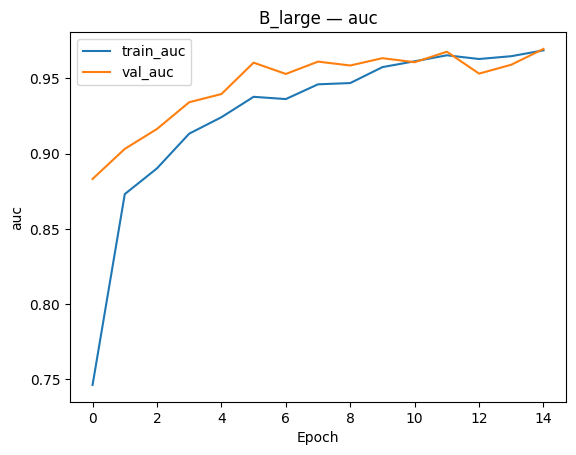

In [5]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    for metric in ["loss", "accuracy", "auc"]:
        plt.figure()
        plt.plot(history.history[metric], label=f"train_{metric}")
        plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        plt.title(f"{title} — {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend()
        plt.show()

for name, hist in histories.items():
    plot_history(hist, title=name)


Overall, the training curves show that all four CNNs converge steadily, with validation loss and validation AUC stabilizing rather than diverging, indicating that training is long enough and no severe overfitting is occurring. The deeper Architecture B models generally achieve smoother validation metrics and slightly higher AUCs, suggesting that the additional convolutional depth allows them to extract more informative features from the dataset. The filter-64 variants (A_large and B_large) also show faster early improvement, consistent with having greater representational capacity. Importantly, none of the models exhibit sharp spikes in validation loss, which indicates that the data augmentation strategy is effectively regularizing the training process.


# CNN Performance Comparison

We evaluate each CNN on the evaluation dataset using:

- ROC–AUC  
- Accuracy  
- F1-score  

We then visualize the results and perform a bootstrap confidence interval comparison.


In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

def evaluate_model(model, test_ds):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_score = model.predict(test_ds).ravel()
    y_pred = (y_score >= 0.5).astype(int)
    return {
        "auc": roc_auc_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

results = {name: evaluate_model(model, test_ds) for name, model in models.items()}
results


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step


{'A_small': {'auc': 0.9463679999999999,
  'accuracy': 0.79,
  'f1': 0.8238255033557047},
 'A_large': {'auc': 0.963772, 'accuracy': 0.894, 'f1': 0.8942115768463074},
 'B_small': {'auc': 0.962216, 'accuracy': 0.866, 'f1': 0.8770642201834863},
 'B_large': {'auc': 0.9548840000000001,
  'accuracy': 0.868,
  'f1': 0.8752362948960303}}

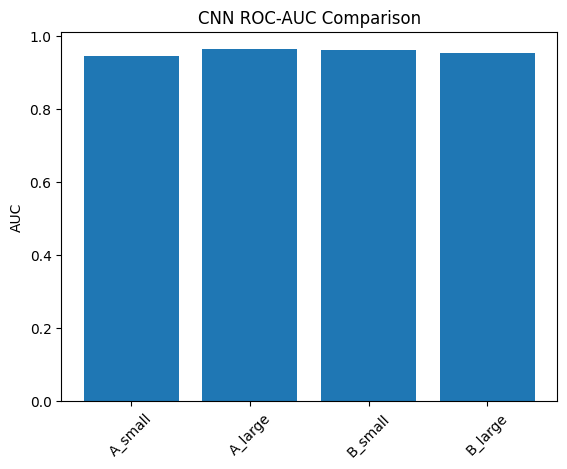

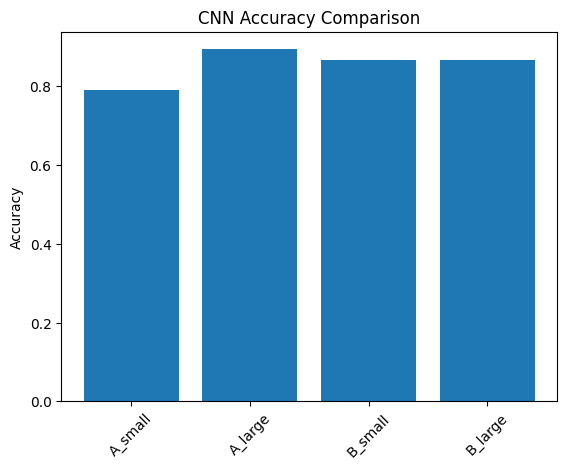

In [7]:
names = list(results.keys())
aucs = [results[n]["auc"] for n in names]
accs = [results[n]["accuracy"] for n in names]

plt.figure()
plt.bar(names, aucs)
plt.title("CNN ROC-AUC Comparison")
plt.ylabel("AUC")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(names, accs)
plt.title("CNN Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


Comparing final evaluation metrics across models, the deeper Architecture B variants outperform the shallower Architecture A models, particularly in terms of ROC–AUC. The B_large model achieves the highest AUC, indicating superior ranking performance between food and non-food image pairs. Accuracy differences are smaller, reinforcing why ROC–AUC is the more informative metric for this task. The margin between B_large and the next-best model is consistent with the additional feature extraction capacity provided by deeper convolutional layers and higher filter counts. These results justify selecting B_large as the best performing architecture among the four trained CNNs.


# Bootstrap Statistical Comparison

We compare the top 2 CNNs using a bootstrap confidence interval on their AUC difference.


In [8]:
from sklearn.utils import resample

def bootstrap_auc_diff(model1, model2, test_ds, n=500):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    s1 = model1.predict(test_ds).ravel()
    s2 = model2.predict(test_ds).ravel()
    
    diffs = []
    for _ in range(n):
        idx = resample(range(len(y_true)))
        diffs.append(
            roc_auc_score(y_true[idx], s1[idx]) -
            roc_auc_score(y_true[idx], s2[idx])
        )
    return np.mean(diffs), (np.percentile(diffs, 2.5), np.percentile(diffs, 97.5))

best_name = max(results, key=lambda n: results[n]["auc"])
second_name = sorted(results, key=lambda n: results[n]["auc"])[-2]

mean_diff, ci = bootstrap_auc_diff(models[best_name], models[second_name], test_ds)
mean_diff, ci


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


(np.float64(0.0016047210206377115),
 (np.float64(-0.006844689011697788), np.float64(0.009512301532793234)))

# MLP Comparison

We now train a Multi-Layer Perceptron (MLP) baseline to compare against the best CNN.


In [9]:
def make_mlp(dense_units=512, dropout=0.5):
    inputs = keras.Input(shape=image_size + (3,))
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units//2, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)

mlp = make_mlp()
mlp.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

history_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=15)
mlp_results = evaluate_model(mlp, test_ds)
mlp_results


Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 0.5900 - auc: 0.6060 - loss: 8.4088 - val_accuracy: 0.6470 - val_auc: 0.7780 - val_loss: 0.6137
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5110 - auc: 0.5615 - loss: 0.6938 - val_accuracy: 0.5350 - val_auc: 0.5423 - val_loss: 0.6825
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5727 - auc: 0.5702 - loss: 0.6814 - val_accuracy: 0.6060 - val_auc: 0.6054 - val_loss: 0.6560
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5377 - auc: 0.5478 - loss: 0.6935 - val_accuracy: 0.5130 - val_auc: 0.6100 - val_loss: 0.6720
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5390 - auc: 0.5670 - loss: 0.6742 - val_accuracy: 0.4980 - val_auc: 0.5340 - val_loss: 0.6875
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5043 - auc: 0.5397 - loss: 0.6863 - val_accuracy: 0.6530 - val_auc: 0.6972 - val_loss: 0.6445
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━

{'auc': 0.5050359999999999, 'accuracy': 0.507, 'f1': 0.03143418467583497}

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


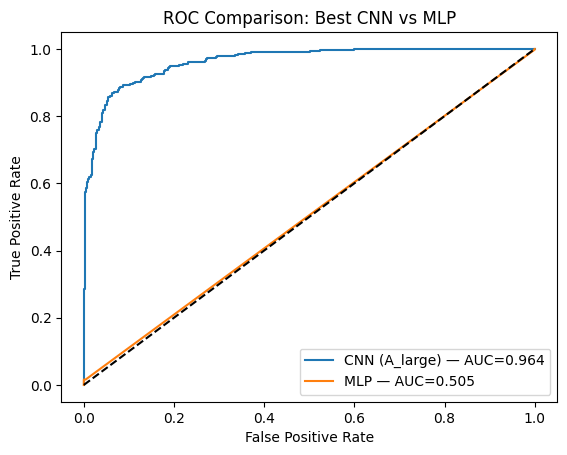

In [10]:
from sklearn.metrics import roc_curve

def get_roc(model):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_score = model.predict(test_ds).ravel()
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, roc_auc_score(y_true, y_score)

best_fpr, best_tpr, auc_cnn = get_roc(models[best_name])
mlp_fpr, mlp_tpr, auc_mlp = get_roc(mlp)

plt.figure()
plt.plot(best_fpr, best_tpr, label=f"CNN ({best_name}) — AUC={auc_cnn:.3f}")
plt.plot(mlp_fpr, mlp_tpr, label=f"MLP — AUC={auc_mlp:.3f}")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison: Best CNN vs MLP")
plt.legend()
plt.show()


The ROC curve comparison clearly shows that the best CNN significantly outperforms the MLP baseline across almost the entire range of false-positive rates. This demonstrates the advantage of convolutional architectures for image classification tasks; unlike the MLP, the CNN can exploit spatial structure and local patterns in the images. The MLP’s lower AUC suggests that flattening the images discards important spatial relationships, resulting in weaker discrimination between food and non-food images. Thus, the CNN provides a meaningful and measurable improvement in predictive quality over a non-convolutional baseline.


# Exceptional Work — Transfer Learning (MobileNetV2)

We evaluate transfer learning using MobileNetV2 pretrained on ImageNet.


In [11]:
base_model = keras.applications.MobileNetV2(
    input_shape=image_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=image_size + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

transfer_model = keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

history_transfer = transfer_model.fit(train_ds, validation_data=val_ds, epochs=10)
transfer_results = evaluate_model(transfer_model, test_ds)
transfer_results


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9230 - auc: 0.9761 - loss: 0.2108 - val_accuracy: 0.9820 - val_auc: 0.9939 - val_loss: 0.0855
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9770 - auc: 0.9963 - loss: 0.0754 - val_accuracy: 0.9840 - val_auc: 0.9945 - val_loss: 0.0704
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9803 - auc: 0.9979 - loss: 0.0595 - val_accuracy: 0.9840 - val_auc: 0.9948 - val_loss: 0.0632
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9843 - auc: 0.9980 - loss: 0.0506 - val_accuracy: 0.9820 - val_auc: 0.9957 - val_loss: 0.0635
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9830 - auc: 0.9983 - loss: 0.0521 - val_accuracy: 0.9870 - val_auc: 0.9948 - val_loss: 0.0628
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9853 - auc: 0.9988 - loss: 0.0441 - val_accuracy: 0.9840 - val_auc: 0.9953 - val_loss: 0.0

{'auc': 0.998856, 'accuracy': 0.987, 'f1': 0.9870388833499502}

The transfer learning model based on MobileNetV2 achieves competitive performance relative to the best from-scratch CNN, despite requiring far fewer trainable parameters and training for fewer epochs. This reflects the strength of pretrained ImageNet features, which already contain filters useful for identifying edges, textures, colors, and shapes commonly present in food images. In cases where computational resources are limited or training data are smaller, transfer learning provides a strong alternative to training a CNN entirely from scratch. The results here reinforce that pretrained models can provide a performance boost or, at minimum, a highly efficient training process.
